# nb_02 — Light-curve property histograms

Goal (see `docs/SPEC_V01.md`, rough plan step 2): histograms for `nDiaSources`, and per-object
light-curve statistics — duration, cadence, amplitude — computed from the nested `diaSource`
column via `lsdb`'s `map_rows`. Works on the subset nb_01 wrote to `dp2_subset`.

**Resolves one of the spec's open questions.** `diaSource` carries both a difference-image
flux/mag (`psfFlux`/`psfMag` — noisy, sometimes negative → `NaN` mag) *and* an absolute,
calibrated science-image flux/mag (`scienceFlux`/`scienceMag` — a stable per-epoch baseline
value, confirmed against nb_01's subset). So the "diff fluxes aren't informative for
histograms" concern doesn't need a fix (no mag conversion, no Object-catalog crossmatch) —
`scienceMag` already works directly for amplitude-style statistics.

**Deferred to later, not attempted here:** the spec's rise/fall/peak-location stats for
detected transients need an actual transient-detection criterion first, which belongs with
the type-specific search work in the spec's "Specific types search" section, not a
general-purpose histogram notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lsdb
from datapaths import Datapaths

dp = Datapaths()
subset_cat = lsdb.open_catalog(dp["dp2_subset"] / "dia_object_lc_10plus")
print(subset_cat.npartitions, "partitions")
subset_cat

4 partitions


,dec,diaObjectId,nDiaSources,ra,tract,diaObjectForcedSource,diaSource,field
npartitions=4,,,,,,,,
"Order: 1, Pixel: 17",double[pyarrow],int64[pyarrow],int64[pyarrow],double[pyarrow],int64[pyarrow],"nested<band: [string], coord_dec: [double], co...","nested<band: [string], centroid_flag: [bool], ...",string[pyarrow]
"Order: 1, Pixel: 34",...,...,...,...,...,...,...,...
"Order: 1, Pixel: 41",...,...,...,...,...,...,...,...
"Order: 1, Pixel: 47",...,...,...,...,...,...,...,...


## 1. `nDiaSources` histograms

`nDiaSources` is a flat (non-nested) column, so this is a plain `.compute()` + `plt.hist` —
no `map_rows` needed. We already filtered to `> 10` in nb_01, so the histogram starts there;
`field` (added when nb_01 combined its 5 cone-searched fields) lets us split by field too.

In [2]:
flat_df = subset_cat[["diaObjectId", "nDiaSources", "field"]].compute()
print(flat_df.shape)
flat_df["nDiaSources"].describe()

Computing Catalog:   0%|          | 0/8 [00:00<?, ?it/s]

(7036, 3)


count       7036.0
mean     19.055287
std      12.560017
min           11.0
25%           13.0
50%           16.0
75%           20.0
max          194.0
Name: nDiaSources, dtype: double[pyarrow]

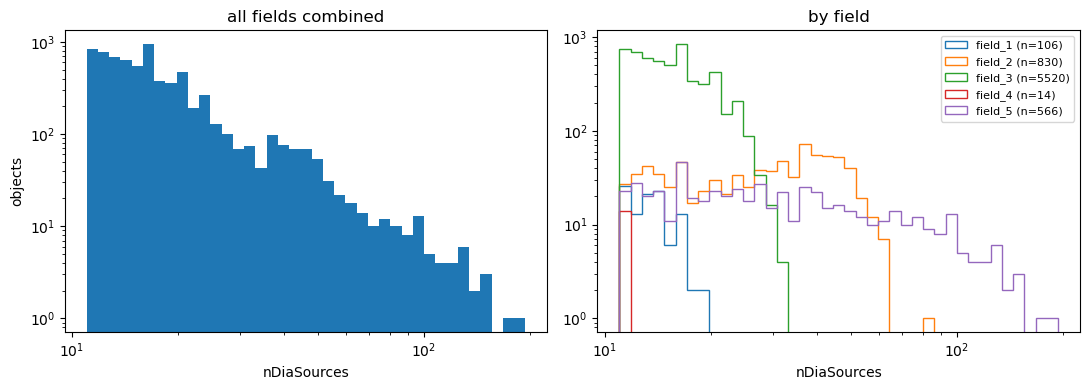

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

bins = np.logspace(np.log10(flat_df["nDiaSources"].min()), np.log10(flat_df["nDiaSources"].max()), 40)

axes[0].hist(flat_df["nDiaSources"], bins=bins, color="C0")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("nDiaSources")
axes[0].set_ylabel("objects")
axes[0].set_title("all fields combined")

for field_name, group in flat_df.groupby("field"):
    axes[1].hist(group["nDiaSources"], bins=bins, histtype="step", label=f"{field_name} (n={len(group)})")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("nDiaSources")
axes[1].legend(fontsize=8)
axes[1].set_title("by field")

fig.tight_layout()

## 2. Per-object light-curve statistics via `map_rows`

`catalog.map_rows(func, columns=[...], meta=...)` runs `func` once per top-level row (one
diaObject), handing it the requested nested sub-columns as plain numpy arrays — the same
pattern would work unchanged on the full lazy collection, not just this small computed
subset, which is the point of using it here instead of a plain pandas `.apply` after
`.compute()`.

Two deliberate choices, both because bands don't share a cadence (same issue the spec flags
for color computation):
- **Duration and cadence gap use all bands combined** — they're about time sampling, not
  flux, so mixing bands is fine and matches "how long/how densely was this object monitored,
  period" rather than a per-band question.
- **Amplitude is computed per band** (`{band}_amp_p90p10`), *never* mixing bands — a g-band
  and r-band magnitude differ by the object's color, not by variability, so combining them
  would inflate "amplitude" with a color offset rather than measure real variation. We use
  the 10th-90th percentile range rather than min/max, per the spec's "robust-amplitude (with
  outliers discarded)" — a couple of noisy points at the tails don't blow up the estimate.

In [4]:
BANDS = "ugrizy"


def lc_stats(row):
    t = np.asarray(row["diaSource.midpointMjdTai"], dtype=float)
    mag = np.asarray(row["diaSource.scienceMag"], dtype=float)
    band = np.asarray(row["diaSource.band"])

    order = np.argsort(t)
    t, mag, band = t[order], mag[order], band[order]

    duration = float(t[-1] - t[0]) if len(t) > 1 else 0.0
    gaps = np.diff(t)
    median_gap = float(np.median(gaps)) if len(gaps) > 0 else np.nan

    out = {"duration_days": duration, "median_cadence_gap_days": median_gap}
    for b in BANDS:
        band_mag = mag[band == b]
        band_mag = band_mag[np.isfinite(band_mag)]
        # require >= 3 points so the percentile range means something
        out[f"{b}_amp_p90p10"] = (
            float(np.percentile(band_mag, 90) - np.percentile(band_mag, 10))
            if len(band_mag) >= 3
            else np.nan
        )
    return pd.Series(out)


meta = {"duration_days": "f8", "median_cadence_gap_days": "f8"}
meta |= {f"{b}_amp_p90p10": "f8" for b in BANDS}

lc_stats_cat = subset_cat.map_rows(
    lc_stats,
    columns=["diaSource.midpointMjdTai", "diaSource.scienceMag", "diaSource.band"],
    meta=meta,
)
stats_df = lc_stats_cat.compute()
print(stats_df.shape)
stats_df.describe()

Computing Catalog:   0%|          | 0/8 [00:00<?, ?it/s]

(7036, 8)


,duration_days,median_cadence_gap_days,u_amp_p90p10,g_amp_p90p10,r_amp_p90p10,i_amp_p90p10,z_amp_p90p10,y_amp_p90p10
count,7036.000000,7036.000000,5.000000,3309.000000,4498.000000,3591.000000,6328.000000,696.000000
mean,45.187674,0.615913,0.039399,0.227874,0.254391,0.355222,0.384298,0.158771
std,42.470980,0.892313,0.035954,0.192708,0.275321,0.333630,0.279678,0.225414
min,1.207915,0.000437,0.011276,0.002046,0.001091,0.002051,0.002133,0.003609
25%,19.238753,0.118110,0.018713,0.103253,0.095623,0.119540,0.194613,0.023428
50%,31.121888,0.497167,0.022113,0.175622,0.178347,0.247485,0.324041,0.059562
75%,32.139446,0.898878,0.045348,0.286583,0.319919,0.492088,0.525242,0.205084
max,190.879476,16.517791,0.099546,2.726620,4.559618,3.457497,4.362378,1.566138


## 3. Histograms: duration and cadence gap

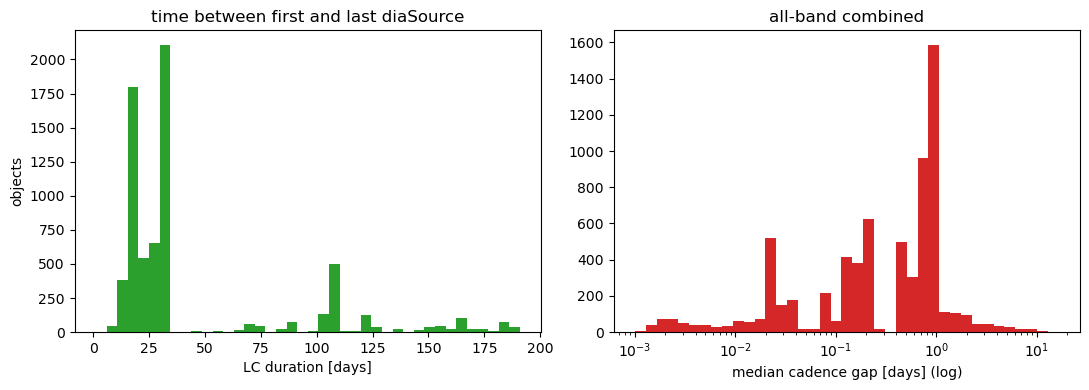

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(stats_df["duration_days"], bins=40, color="C2")
axes[0].set_xlabel("LC duration [days]")
axes[0].set_ylabel("objects")
axes[0].set_title("time between first and last diaSource")

gap = stats_df["median_cadence_gap_days"]
axes[1].hist(gap[gap > 0], bins=np.logspace(np.log10(max(gap[gap > 0].min(), 1e-3)), np.log10(gap.max()), 40), color="C3")
axes[1].set_xscale("log")
axes[1].set_xlabel("median cadence gap [days] (log)")
axes[1].set_title("all-band combined")

fig.tight_layout()

## 4. Histograms: per-band robust amplitude

One panel per band, so the very different sample sizes per band (`u` in particular — DP2's
LSSTCam observations spent little time there) stay visible rather than getting averaged away.

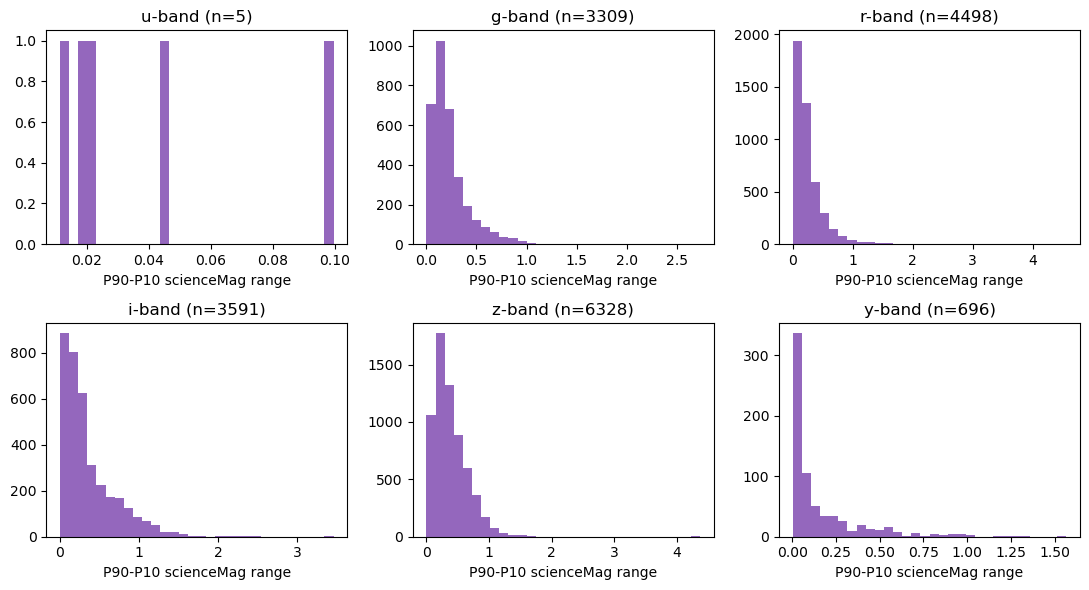

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(11, 6))

for ax, b in zip(axes.flat, BANDS):
    values = stats_df[f"{b}_amp_p90p10"].dropna()
    if len(values) > 0:
        ax.hist(values, bins=30, color="C4")
    ax.set_title(f"{b}-band (n={len(values)})")
    ax.set_xlabel("P90-P10 scienceMag range")

fig.tight_layout()

## 5. Save the statistics — into the collection, not a side file

Per the spec: no need to recompute these every time. First attempt at this was a separate
`dp.save()` parquet, joinable on `diaObjectId` — technically fine (that table has no nested
columns, so flattening it was the right call), but it duplicates the object table and forces
every consumer to do a join for something that's really just more columns on the same
objects.

`dia_object_lc_10plus` itself has nested columns (`diaSource`, `diaObjectForcedSource`), so
per the same principle in reverse: don't flatten it to force it through `dp.save`. Assign the
new stat columns onto the already-nested frame and write it with `lsdb`'s own `write_catalog`
(confirmed nested + new flat columns round-trip together through `from_dataframe` +
`write_catalog` + reopen), then `dp.register` a pointer to it — the same pattern nb_01 uses
for the base subset.

**Written as a new collection (`..._with_stats`), not overwriting `dia_object_lc_10plus`
in place:** nb_01 still writes that path with `overwrite=True` whenever it's rerun (e.g. with
different `FIELDS`), which would silently wipe out anything nb_02 added if we reused the same
name. Keeping nb_01's output the untouched "base" and nb_02's the derived collection means
rerunning either notebook can't clobber the other's work.

In [7]:
nested_df = subset_cat.compute()
stat_cols = ["duration_days", "median_cadence_gap_days"] + [f"{b}_amp_p90p10" for b in BANDS]
merged_df = nested_df.assign(**{col: stats_df[col] for col in stat_cols})
print(merged_df.shape, merged_df.columns.tolist())

with_stats_cat = lsdb.from_dataframe(merged_df)
with_stats_path = dp["dp2_subset"] / "dia_object_lc_10plus_with_stats"
with_stats_cat.write_catalog(with_stats_path, overwrite=True, create_thumbnail=False, progress_bar=False)
print("wrote", with_stats_path)

dp.register(
    name="dia_object_lc_10plus_with_stats",
    type="dp2_subset",
    fmt="hats-collection",
    src_path=str(with_stats_path / "collection.properties"),
    tags=["nb02", "dp2", "diaObject", "lc-stats"],
    inputs=["dia_object_lc_10plus"],
    notes=(
        "dia_object_lc_10plus plus duration_days, median_cadence_gap_days (all bands) and "
        "{band}_amp_p90p10 (per band, scienceMag) columns, from nb_02."
    ),
    overwrite_history=True,
)
dp.print_paths(name="dia_object_lc_10plus_with_stats")

Computing Catalog:   0%|          | 0/4 [00:00<?, ?it/s]

(7036, 16) ['dec', 'diaObjectId', 'nDiaSources', 'ra', 'tract', 'diaObjectForcedSource', 'diaSource', 'field', 'duration_days', 'median_cadence_gap_days', 'u_amp_p90p10', 'g_amp_p90p10', 'r_amp_p90p10', 'i_amp_p90p10', 'z_amp_p90p10', 'y_amp_p90p10']


wrote /home/shrra-ung/share/trieste/dia_object_lc_10plus_with_stats
name                            | path                                                                                | tags                        | type       | updated at               
--------------------------------+-------------------------------------------------------------------------------------+-----------------------------+------------+--------------------------
dia_object_lc_10plus_with_stats | /home/shrra-ung/share/trieste/dia_object_lc_10plus_with_stats/collection.properties | diaobject,dp2,lc-stats,nb02 | dp2_subset | 2026-08-27T18:50:13+00:00


## Next

`dia_object_lc_10plus_with_stats` is registered and has the light curves plus the new stat
columns together — no join needed. nb_03 picks up from here for color-mag/color-color plots.

Open questions carried forward, not resolved here:
- **Simplify section 5 with `map_rows(..., append_columns=True)`.** Confirmed it returns the
  catalog with the original columns plus the new stat columns already merged, applied
  directly to the lazy `subset_cat` — no separate `nested_df = subset_cat.compute()` +
  `nested_df.assign(...)` step needed. Should collapse sections 2 and 5's write step into one
  `map_rows(..., append_columns=True)` call feeding straight into `write_catalog`.
- Whether P90-P10 is the right robustness choice, or something else (sigma-clipped std, MAD)
  would serve nb_04's period-finding work better as a shared amplitude definition.
- `median_cadence_gap_days` mixes bands; worth adding a per-band version once it's clear
  whether nb_04's period search wants combined or per-band cadence.
- Rewriting the whole collection every time a stat definition changes is fine at this size
  (7,036 objects) but won't scale to `dp2_filtered` (~300 GB) — worth revisiting whether
  `map_rows` + `write_catalog` is still the right approach there, or whether stats should
  stay a separate, cheaply-regenerable side table once the target is the full collection.
- This entire notebook only ran against nb_01's small 5-field subset — none of it has been
  checked against `dp2_filtered` for performance at scale.